# Lesson 4: running a LeRobot policy on the dataset

A policy is a function from one frame's observations to the next few seconds of robot commands. Lessons 1 to 3 built the frames; this lesson feeds them to a trained policy and compares what it predicts with what the human actually did.

The policy is `lerobot/act_aloha_sim_insertion_human`: ACT (Action Chunking Transformer), 52 M parameters, trained on this dataset. Every LeRobot policy, ACT or a vision-language-action model like SmolVLA, is loaded, fed, and read the same way, so what you learn here transfers.

You will be able to:

1. Load a pretrained policy and read the contract it declares
2. Test a dataset against that contract before running anything
3. Build the pre/post-processor pipeline and know what each step does
4. Predict an action chunk for one frame and compare it to ground truth
5. Run the policy from a FiftyOne sample (road 1) and over a FiftyOne view (road 2), writing results back

Dataset: `lerobot-aloha-sim-insertion-human`. Env: `fo_lerobot`, GPU. First run downloads the ~200 MB checkpoint.

This notebook **writes** one float field (`act_mse`) to the FiftyOne dataset. Section 7 depends on Lesson 3's `traj_outlier` tag for a comparison, but runs without it.

## 1. Load the policy and read its contract

Every LeRobot policy is a `PreTrainedPolicy`; `from_pretrained` pulls `config.json` and `model.safetensors` from the Hub. The config declares the contract:

- `input_features`: what the policy needs per frame, by key, type, and shape
- `output_features`: what it produces
- `chunk_size`: how many future actions it predicts at once (ACT: 100 frames = 2 s at 50 fps)
- `n_action_steps`: how many of those it actually executes before predicting again

Expect a warning about **unexpected keys** `normalize_inputs.*` / `unnormalize_outputs.*`. This checkpoint predates lerobot 0.6: normalization used to live inside the model. It now lives in a separate processor pipeline (section 3), so the loader drops those buffers. Keep that warning in mind; section 3 shows what replaces them.

In [1]:
import copy
import logging
import os
from collections import defaultdict

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
logging.getLogger("lerobot").setLevel(logging.ERROR)

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file

import fiftyone as fo
from fiftyone import ViewField as F
from lerobot.configs.policies import PreTrainedConfig
from lerobot.datasets.lerobot_dataset import LeRobotDataset, LeRobotDatasetMetadata
from lerobot.policies.act.modeling_act import ACTPolicy
from lerobot.policies.factory import make_pre_post_processors
from lerobot.utils.constants import IMAGENET_STATS
from lerobot.utils.feature_utils import dataset_to_policy_features

POLICY_REPO = "lerobot/act_aloha_sim_insertion_human"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

policy = ACTPolicy.from_pretrained(POLICY_REPO).to(DEVICE).eval()
cfg = policy.config

print("policy type:    ", cfg.type)
print("params:         ", round(sum(p.numel() for p in policy.parameters()) / 1e6, 1), "M")
print("chunk_size:     ", cfg.chunk_size, "   n_action_steps:", cfg.n_action_steps, "   n_obs_steps:", cfg.n_obs_steps)
print()
print("input_features:")
for k, f in cfg.input_features.items():
    print(f"  {k:28s} {f.type.name:8s} {f.shape}")
print("output_features:")
for k, f in cfg.output_features.items():
    print(f"  {k:28s} {f.type.name:8s} {f.shape}")
print()
print("normalization_mapping:", {str(k): getattr(v, "name", v) for k, v in cfg.normalization_mapping.items()})

policy type:     act
params:          51.6 M
chunk_size:      100    n_action_steps: 100    n_obs_steps: 1

input_features:
  observation.images.top       VISUAL   (3, 480, 640)
  observation.state            STATE    (14,)
output_features:
  action                       ACTION   (14,)

normalization_mapping: {'VISUAL': 'MEAN_STD', 'STATE': 'MEAN_STD', 'ACTION': 'MEAN_STD'}


## 2. Test the dataset against the contract

`dataset_to_policy_features(meta.features)` converts a dataset's `meta/info.json` features into the same `PolicyFeature` objects a policy config uses. Compare key by key and shape by shape. Do this before any inference; it is a 1 ms test that saves a confusing CUDA error later.

The same test against a checkpoint for a different robot shows what failure looks like. `lerobot/smolvla_base` is a vision-language-action model trained on a 6-joint SO-100 arm with three cameras; only its `config.json` is downloaded here. Every mismatch it reports is a real reason that checkpoint cannot run on aloha frames, however the keys are renamed.

In [2]:
dataset = fo.load_dataset("lerobot-aloha-sim-insertion-human")
root = dataset.media_sources[0]["loc"]                                  # Lesson 2 road 1
meta = LeRobotDatasetMetadata("lerobot/aloha_sim_insertion_human", root=root)

ds_features = dataset_to_policy_features(meta.features)

def check_contract(policy_cfg, ds_features, label):
    """Print, per policy feature, whether the dataset provides it at the right shape."""
    print(f"== {label}")
    ok = True
    for key, want in {**policy_cfg.input_features, **policy_cfg.output_features}.items():
        have = ds_features.get(key)
        if have is None:
            print(f"  MISSING  {key:28s} policy wants {want.shape}")
            ok = False
        elif tuple(have.shape) != tuple(want.shape):
            print(f"  SHAPE    {key:28s} policy wants {want.shape}, dataset has {have.shape}")
            ok = False
        else:
            print(f"  ok       {key:28s} {want.shape}")
    print("  compatible:", ok)

check_contract(cfg, ds_features, POLICY_REPO)
print()
smolvla_cfg = PreTrainedConfig.from_pretrained("lerobot/smolvla_base")   # downloads config.json only
check_contract(smolvla_cfg, ds_features, "lerobot/smolvla_base")

== lerobot/act_aloha_sim_insertion_human
  ok       observation.images.top       (3, 480, 640)
  ok       observation.state            (14,)
  ok       action                       (14,)
  compatible: True

== lerobot/smolvla_base
  SHAPE    observation.state            policy wants (6,), dataset has (14,)
  MISSING  observation.images.camera1   policy wants (3, 256, 256)
  MISSING  observation.images.camera2   policy wants (3, 256, 256)
  MISSING  observation.images.camera3   policy wants (3, 256, 256)
  SHAPE    action                       policy wants (6,), dataset has (14,)
  compatible: False


## 3. The processor pipeline

The network never sees raw frames. In lerobot 0.6 everything between a dataset frame and the network is a **pre-processor pipeline**, and everything between the network's output and a usable action is a **post-processor pipeline**. For ACT:

| pre-processor step | does |
|---|---|
| `RenameObservations` | maps your dataset's keys to the keys the checkpoint expects (identity here) |
| `AddBatchDimension` | turns a single frame into a batch of 1 |
| `Device` | moves tensors to the GPU |
| `Normalizer` | `(x - mean) / std` per feature, using stats you pass in |

| post-processor step | does |
|---|---|
| `Unnormalizer` | `x * std + mean` on the predicted actions |
| `Device` | moves back to CPU |

New checkpoints ship these pipelines as `policy_preprocessor.json` next to the weights. This one does not, so `make_pre_post_processors(policy.config, dataset_stats=...)` builds them from the config and the stats we give it.

**Which stats?** Two facts, both checked in the cell:

1. The state/action buffers the loader dropped in section 1 are equal to `meta.stats` to 1e-7. The checkpoint was trained on this dataset, so dataset stats are the right ones.
2. The image buffers are **not** dataset stats. They are ImageNet mean/std (0.485, 0.456, 0.406), because ACT's ResNet-18 backbone is ImageNet-pretrained and LeRobot training substitutes them by default (`use_imagenet_stats=True`). We do the same substitution, or the backbone sees images in the wrong range. Section 5 measures the damage if you forget.

In [3]:
# 1) the dropped buffers vs the dataset stats
ckpt = load_file(hf_hub_download(POLICY_REPO, "model.safetensors"))
comparisons = [
    # label,          checkpoint buffer,                                       dataset stat
    ("state mean",   "normalize_inputs.buffer_observation_state.mean",       meta.stats["observation.state"]["mean"]),
    ("state std",    "normalize_inputs.buffer_observation_state.std",        meta.stats["observation.state"]["std"]),
    ("action mean",  "normalize_targets.buffer_action.mean",                 meta.stats["action"]["mean"]),
    ("image mean",   "normalize_inputs.buffer_observation_images_top.mean",  meta.stats["observation.images.top"]["mean"]),
]
for label, key, ds_stat in comparisons:
    ck = ckpt[key].numpy().ravel()
    gap = np.abs(ck - np.asarray(ds_stat).ravel()).max()
    print(f"{label:12s} max|ckpt - dataset| = {gap:.1e}   ckpt[:3] = {np.round(ck[:3], 3)}")

# 2) stats for the processors: dataset stats, cameras swapped to ImageNet
stats = copy.deepcopy(meta.stats)
for cam in meta.camera_keys:
    for name, value in IMAGENET_STATS.items():
        stats[cam][name] = torch.tensor(value, dtype=torch.float32)

preprocess, postprocess = make_pre_post_processors(
    cfg,
    dataset_stats=stats,
    preprocessor_overrides={"device_processor": {"device": DEVICE}},
)
print()
print("pre: ", [type(s).__name__.replace("ProcessorStep", "") for s in preprocess.steps])
print("post:", [type(s).__name__.replace("ProcessorStep", "") for s in postprocess.steps])

state mean   max|ckpt - dataset| = 2.8e-07   ckpt[:3] = [ 0.008 -0.187  0.738]
state std    max|ckpt - dataset| = 1.0e-07   ckpt[:3] = [0.109 0.224 0.203]
action mean  max|ckpt - dataset| = 7.2e-07   ckpt[:3] = [ 0.008 -0.182  0.732]
image mean   max|ckpt - dataset| = 3.2e-01   ckpt[:3] = [0.485 0.456 0.406]

pre:  ['RenameObservations', 'AddBatchDimension', 'Device', 'Normalizer']
post: ['Unnormalizer', 'Device']


## 4. One frame in, one action chunk out

The dataset side is Lesson 1 section 7: ask `LeRobotDataset` for the next `chunk_size` actions per frame with `delta_timestamps`, and the ground-truth chunk arrives as `frame["action"]` with shape `(100, 14)`.

The policy side is three calls:

1. `preprocess(obs)`: `obs` is the frame's `observation.*` entries plus `task`
2. `policy.predict_action_chunk(batch)`: the network, returns `(1, 100, 14)` in normalized space
3. `postprocess(chunk)`: back to joint units

Compare against the recorded chunk with per-dimension MSE. The baseline to beat is "hold the current state for 2 s": if the policy is not far below that, it learned nothing. Expect ~0.0001 vs ~0.018, about 100× better. One caveat on every number in this lesson: the checkpoint was trained on these same 50 episodes, so this is fit to the training set, not a generalization test.

`select_action` is the deployment wrapper around the same call: it predicts a chunk, keeps the first `n_action_steps` in a queue, and hands them out one per call until the queue is empty. `policy.reset()` clears it. Use `predict_action_chunk` for analysis and `select_action` when driving a robot.

pred (100, 14)  gt (100, 14)
per-dim MSE: [9.0e-05 8.0e-05 5.0e-05 3.0e-05 1.7e-04 1.0e-05 1.0e-03 2.0e-05 6.0e-05
 5.0e-05 6.0e-05 9.0e-05 7.0e-05 2.0e-05]
mean MSE  policy 0.00013   hold-state baseline 0.01801


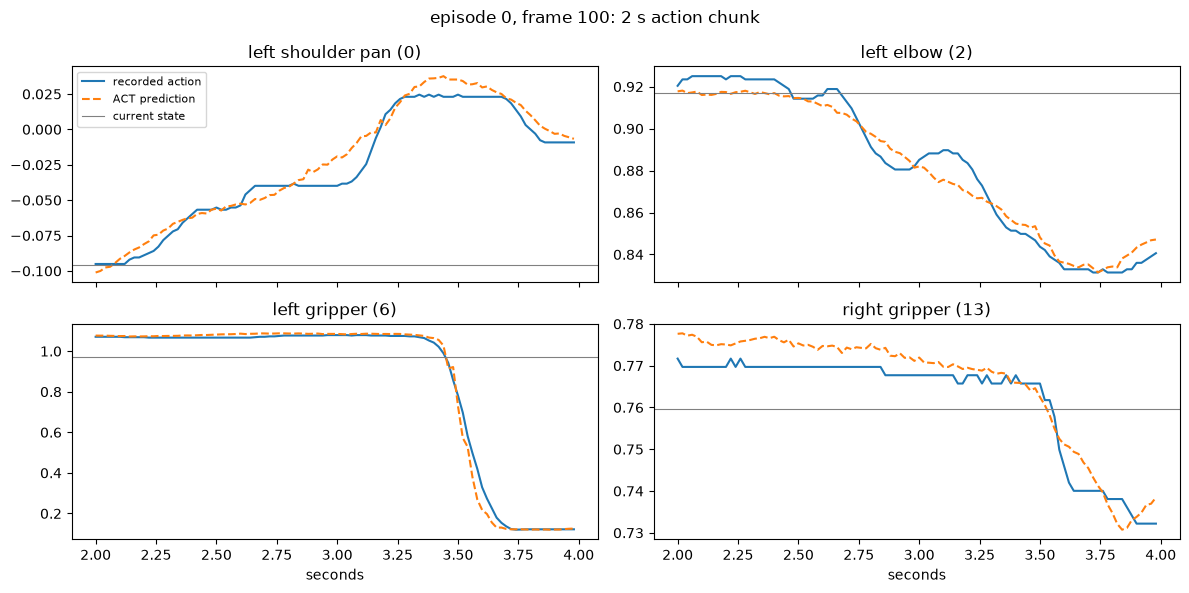

select_action -> (1, 14)   equals chunk[0]: True


In [4]:
fps = meta.fps
delta_timestamps = {"action": [i / fps for i in range(cfg.chunk_size)]}      # the next 100 actions per frame

def observation_of(frame):
    """The policy's input: every observation.* entry plus the task string."""
    obs = {k: v for k, v in frame.items() if k.startswith("observation.")}
    obs["task"] = frame["task"]
    return obs

@torch.inference_mode()
def predict_chunk(frame):
    """frame -> (chunk_size, action_dim) numpy array in joint units."""
    batch = preprocess(observation_of(frame))
    chunk = policy.predict_action_chunk(batch)
    return postprocess(chunk)[0].cpu().numpy()

episode0 = LeRobotDataset("lerobot/aloha_sim_insertion_human", root=root, episodes=[0], delta_timestamps=delta_timestamps)
FRAME = 100
frame = episode0[FRAME]

pred = predict_chunk(frame)
gt = frame["action"].numpy()
hold = np.repeat(frame["observation.state"].numpy()[None], cfg.chunk_size, axis=0)

mse_dim = ((pred - gt) ** 2).mean(axis=0)
print("pred", pred.shape, " gt", gt.shape)
print("per-dim MSE:", np.round(mse_dim, 5))
print(f"mean MSE  policy {mse_dim.mean():.5f}   hold-state baseline {((hold - gt) ** 2).mean():.5f}")

t = FRAME / fps + np.arange(cfg.chunk_size) / fps
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
for ax, d, name in zip(axes.ravel(), [0, 2, 6, 13], ["left shoulder pan (0)", "left elbow (2)", "left gripper (6)", "right gripper (13)"]):
    ax.plot(t, gt[:, d], label="recorded action")
    ax.plot(t, pred[:, d], "--", label="ACT prediction")
    ax.axhline(hold[0, d], color="gray", lw=0.8, label="current state")
    ax.set_title(name)
axes[0, 0].legend(fontsize=8)
for ax in axes[1]:
    ax.set_xlabel("seconds")
plt.suptitle(f"episode 0, frame {FRAME}: 2 s action chunk")
plt.tight_layout(); plt.show()

policy.reset()
with torch.inference_mode():
    first = postprocess(policy.select_action(preprocess(observation_of(frame))))
print("select_action ->", tuple(first.shape), "  equals chunk[0]:", np.allclose(first[0].cpu().numpy(), pred[0], atol=1e-5))

## 5. The stats gotcha, measured

Same policy, same 50 frames, two processor pipelines: one built from raw `meta.stats` (dataset image mean ≈ 0.16, a dark simulator scene) and one with ImageNet camera stats. The backbone was trained on the second. Expect roughly 2× the error with the first. Nothing crashes, which is why this bug survives in real code.

In [5]:
@torch.inference_mode()
def mean_chunk_mse(pre, post, frames):
    errs = []
    for f in frames:
        pred = post(policy.predict_action_chunk(pre(observation_of(f))))[0].cpu().numpy()
        errs.append(((pred - f["action"].numpy()) ** 2).mean())
    return float(np.mean(errs))

frames = [episode0[i] for i in range(0, 400, 8)]                          # 50 frames across the episode

pre_raw, post_raw = make_pre_post_processors(cfg, dataset_stats=meta.stats,
                                             preprocessor_overrides={"device_processor": {"device": DEVICE}})
print(f"dataset image stats  mean MSE {mean_chunk_mse(pre_raw, post_raw, frames):.5f}")
print(f"ImageNet image stats mean MSE {mean_chunk_mse(preprocess, postprocess, frames):.5f}")

dataset image stats  mean MSE 0.00039


ImageNet image stats mean MSE 0.00017


## 6. Road 1: from a FiftyOne sample to a prediction

Lesson 2 section 5, now with a policy at the end. Any code that FiftyOne hands a **sample** to (a `fiftyone.Model`, an operator, a plain function) has to get from there to a frame the policy accepts:

1. `sample.episode_index` → which episode; `dataset.media_sources[0]["loc"]` → which folder
2. `LeRobotDataset(root=..., episodes=[that one], delta_timestamps=...)` → the episode's frames, with ground-truth chunks attached
3. pick a frame, call `predict_chunk`

`predict_for_sample` below is that path as one function. Its body is what `Model.predict` will contain. The only FiftyOne-specific lines are the first two.

In [6]:
def predict_for_sample(sample, frame_idx):
    """FiftyOne sample -> (predicted chunk, ground-truth chunk) at frame_idx of that episode."""
    ep_root = sample.dataset.media_sources[0]["loc"]                     # where the frames are
    ep = LeRobotDataset("lerobot/aloha_sim_insertion_human", root=ep_root,
                        episodes=[sample.episode_index], delta_timestamps=delta_timestamps)
    frame = ep[frame_idx]
    return predict_chunk(frame), frame["action"].numpy()

sample = dataset.match(F("episode_index") == 36).first()                # Lesson 3's most hesitant demo
pred, gt = predict_for_sample(sample, frame_idx=150)
print(f"episode {sample.episode_index}, frame 150: chunk MSE {((pred - gt) ** 2).mean():.5f}")

session = fo.launch_app(dataset, auto=False)
session.view = dataset.match(F("episode_index") == 36)
print("App:", session.url, " (showing episode 36; scrub to 3.0 s = frame 150)")

episode 36, frame 150: chunk MSE 0.00026
Connected to FiftyOne on port 5151 at localhost.
If you are not connecting to a remote session, you may need to start a new session and specify a port


INFO:fiftyone.core.service:Connected to FiftyOne on port 5151 at localhost.
If you are not connecting to a remote session, you may need to start a new session and specify a port


Session launched. Run `session.show()` to open the App in a cell output.


INFO:fiftyone.core.session.session:Session launched. Run `session.show()` to open the App in a cell output.


App: http://localhost:5151/  (showing episode 36; scrub to 3.0 s = frame 150)


## 7. Road 2: a FiftyOne view, batched, results written back

Lesson 2 section 6b with a policy in the loop:

1. the view picks episodes: `dataset.values("episode_index")` (all 50 here; any view works)
2. `LeRobotDataset(episodes=...)` is the torch dataset; a `DataLoader` batches frames. Every 10th frame keeps this to ~2 500 forward passes (~30 s on the GB10)
3. the same `preprocess → predict_action_chunk → postprocess`, now on batches of 32
4. chunk MSE per frame, averaged per episode, `set_values` back onto the samples as `act_mse`

The field then behaves like any other: sort, filter, histogram, sidebar slider. Last line: does the policy find Lesson 3's `traj_outlier` demos harder?

Expect **no**: both groups land at ~0.00018. The reason is the caveat this whole lesson carries: the checkpoint was trained on all 50 of these episodes, so `act_mse` is *training-set fit*. A policy that has seen a demo reproduces it whether or not its motion is unusual. To measure generalization you would hold episodes out, which is exactly what Lesson 3's export of a curated subset is for.

In [7]:
view = dataset                                                            # swap in any view
episodes = view.values("episode_index")

all_eps = LeRobotDataset("lerobot/aloha_sim_insertion_human", root=root, episodes=episodes, delta_timestamps=delta_timestamps)
every_10th = Subset(all_eps, range(0, all_eps.num_frames, 10))
loader = DataLoader(every_10th, batch_size=32, shuffle=False, num_workers=0)
print(len(every_10th), "frames from", len(episodes), "episodes")

sq_err = defaultdict(list)
with torch.inference_mode():
    for batch in loader:
        pred = postprocess(policy.predict_action_chunk(preprocess(observation_of(batch)))).cpu().numpy()   # (B, 100, 14)
        err = ((pred - batch["action"].numpy()) ** 2).mean(axis=(1, 2))                                     # (B,)
        for e, v in zip(batch["episode_index"].tolist(), err.tolist()):
            sq_err[e].append(v)

act_mse = {e: float(np.mean(v)) for e, v in sq_err.items()}
view.set_values("act_mse", [act_mse[e] for e in episodes])

(lo, hi), mean = dataset.aggregate([fo.Bounds("act_mse"), fo.Mean("act_mse")])
print(f"act_mse  min {lo:.5f}  mean {mean:.5f}  max {hi:.5f}")
hardest = dataset.sort_by("act_mse", reverse=True).limit(5)
eps, errs = hardest.values(["episode_index", "act_mse"])
print("hardest episodes for the policy:", list(zip(eps, np.round(errs, 5))))

if "traj_outlier" in dataset.count_sample_tags():
    print(f"mean act_mse  traj_outlier {dataset.match_tags('traj_outlier').mean('act_mse'):.5f}   "
          f"others {dataset.match_tags('traj_outlier', bool=False).mean('act_mse'):.5f}")

session.view = dataset.sort_by("act_mse", reverse=True)

2500 frames from 50 episodes


act_mse  min 0.00012  mean 0.00018  max 0.00041
hardest episodes for the policy: [(48, np.float64(0.00041)), (1, np.float64(0.00027)), (19, np.float64(0.00026)), (47, np.float64(0.00025)), (21, np.float64(0.00023))]
mean act_mse  traj_outlier 0.00018   others 0.00018


## Recap

- A checkpoint declares its contract in `config.input_features` / `output_features`; test the dataset against it with `dataset_to_policy_features` before running anything
- Nothing reaches the network raw: `make_pre_post_processors` builds the rename → batch → device → normalize pipeline and its inverse; the stats you hand it decide whether the policy works (ImageNet for camera features on ACT)
- `predict_action_chunk` returns `chunk_size` future actions; `select_action` is the deployment queue around it
- Road 1: sample → `episodes=[sample.episode_index]` → frame → chunk. Road 2: view → `episodes=view.values(...)` → `DataLoader` → per-episode metric → `set_values`

Where this leads: sections 3, 4, and 6 are the body of a reusable model wrapper. Put them inside a `fiftyone.core.models.Model` subclass and `dataset.apply_model(...)` does what section 7 did, for any view, with no notebook code.

Cleanup: `dataset.delete_sample_field("act_mse")`.